Load Data (Superstore Sales Dataset):

In [1]:
import pandas as pd

df = pd.read_csv("data/train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Inspect Data:

In [2]:
# Basic overview
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [3]:
# Missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

postcal_code has 11 missing values (less than 1% of the entire data).
This specific column is not gonna be used in the analysis, so no further actions are taken, regarding this column and its' 11 missing values.

In [4]:
# Duplicates
df.duplicated().sum()

np.int64(0)

Data Cleaning:
- Standardized column names for consistency
- Converted date columns to datetime format for completeness
- Removed duplicate rows to ensure accurate aggregation

In [5]:
# Clean column names
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")

# Convert date columns
df["order_date"] = pd.to_datetime(df["order_date"], format="%d/%m/%Y")
df["ship_date"] = pd.to_datetime(df["ship_date"], format="%d/%m/%Y")

# Remove duplicate rows
df = df.drop_duplicates()

# Check cleaned data
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9800 non-null   int64         
 1   order_id       9800 non-null   str           
 2   order_date     9800 non-null   datetime64[us]
 3   ship_date      9800 non-null   datetime64[us]
 4   ship_mode      9800 non-null   str           
 5   customer_id    9800 non-null   str           
 6   customer_name  9800 non-null   str           
 7   segment        9800 non-null   str           
 8   country        9800 non-null   str           
 9   city           9800 non-null   str           
 10  state          9800 non-null   str           
 11  postal_code    9789 non-null   float64       
 12  region         9800 non-null   str           
 13  product_id     9800 non-null   str           
 14  category       9800 non-null   str           
 15  sub_category   9800 non-null   s

SQL Queries:

In [6]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False)

9800

Query 1 - Top Customers by Total Sales

(Who are the most valuable customers?)

In [26]:
query_top_customers_by_total_sales = """
SELECT customer_id, customer_name, SUM(sales) AS total_sales
FROM sales
GROUP BY customer_id, customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""

top_customers_by_total_sales = pd.read_sql(query_top_customers_by_total_sales, conn)
top_customers_by_total_sales

,customer_id,customer_name,total_sales
0,SM-20320,Sean Miller,25043.050
1,TC-20980,Tamara Chand,19052.218
2,RB-19360,Raymond Buch,15117.339
3,TA-21385,Tom Ashbrook,14595.620
4,AB-10105,Adrian Barton,14473.571
5,KL-16645,Ken Lonsdale,14175.229
6,SC-20095,Sanjit Chand,14142.334
7,HL-15040,Hunter Lopez,12873.298
8,SE-20110,Sanjit Engle,12209.438
9,CC-12370,Christopher Conant,12129.072


Query 2 - Customer Concentration

(Do a few customers drive most of the revenue?)

In [31]:
query_customer_concentration = """
WITH top_5_customers AS (
    SELECT customer_id, SUM(sales) AS customer_total_sales
    FROM sales
    GROUP BY customer_id
    ORDER BY customer_total_sales DESC
    LIMIT 5
),
top_5_customers_total_sales AS (
SELECT SUM(customer_total_sales) AS sum_of_top_5
FROM top_5_customers
),
total_sales AS (
    SELECT SUM(sales) AS sum_of_total_sales
    FROM sales
)
SELECT (sum_of_top_5 / sum_of_total_sales) * 100 AS top_5_customers_percentage_of_total_sales
FROM top_5_customers_total_sales, total_sales
"""
customer_concentration = pd.read_sql(query_customer_concentration, conn)
customer_concentration


,top_5_customers_percentage_of_total_sales
0,3.90362


Result: The top 5 customers only drive 3.9% of total sales, meaning revenue is broadly distributed across customers, indicating a diversified customer base.

Query 3 - Sales by Customer Segment

(Which segment is most valuable?)

In [40]:
query_sales_by_customer_segment = """
SELECT segment, SUM(sales) as total_sales_per_segment
FROM sales
GROUP BY segment
ORDER BY total_sales_per_segment DESC
"""

sales_by_customer_segment = pd.read_sql(query_sales_by_customer_segment, conn)
sales_by_customer_segment

,segment,total_sales_per_segment
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


Query 4 - Average Order Value per Customer

(How valuable is each customer on average?)

In [65]:
query_average_order_value_per_customer = """
WITH number_of_ord AS (
    SELECT customer_id, customer_name, COUNT(DISTINCT order_id) AS number_of_orders, SUM(sales) AS sum_of_sales
    FROM sales
    GROUP BY customer_id, customer_name
)
SELECT customer_id, customer_name, number_of_orders, (sum_of_sales/number_of_orders) AS average_order_value
FROM number_of_ord
ORDER BY average_order_value DESC
"""

average_order_value_per_customer = pd.read_sql(query_average_order_value_per_customer, conn)
average_order_value_per_customer

,customer_id,customer_name,number_of_orders,average_order_value
0,SM-20320,Sean Miller,5,5008.610000
1,TC-20980,Tamara Chand,5,3810.443600
2,TA-21385,Tom Ashbrook,4,3648.905000
3,GT-14635,Grant Thornton,3,3117.070667
4,BM-11140,Becky Martin,4,2947.407500
...,...,...,...,...
788,SG-20890,Susan Gilcrest,3,15.982000
789,SC-20845,Sung Chung,1,14.112000
790,RS-19870,Roy Skaria,2,11.164000
791,LD-16855,Lela Donovan,1,5.304000


Query 5 - Repeat vs. One-Time Customers

(Are customers returning?)

In [ ]:
query_customer_returnings = """
WITH customer_order_number AS (
SELECT customer_id, COUNT (DISTINCT order_id) AS number_of_orders
FROM sales
GROUP BY customer_id
)
SELECT COUNT(*) AS number_of_customers,
CASE WHEN number_of_orders <= 1 THEN 'one_time' WHEN number_of_orders > 1 THEN 'repeat' END AS customer_type
FROM customer_order_number
GROUP BY customer_type
"""

customer_returnings = pd.read_sql(query_customer_returnings, conn)
customer_returnings

,number_of_customers,customer_type
0,13,one_time
1,780,repeat


Result: The vast majority of customers are repeat customers, with only a very small number of one-time buyers. This suggests strong customer retention and indicates that customers tend to return and place multiple orders.

Visualizations

Top Customers (Bar Chart):

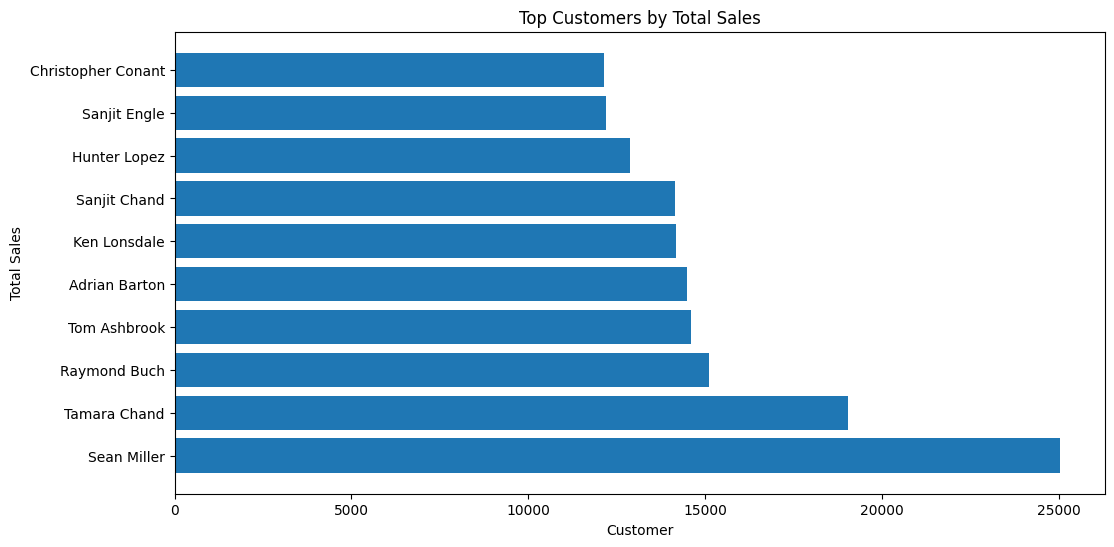

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.barh(top_customers_by_total_sales["customer_name"], top_customers_by_total_sales["total_sales"])

plt.title("Top Customers by Total Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")

plt.show()

Sales by Segment (Bar Chart):

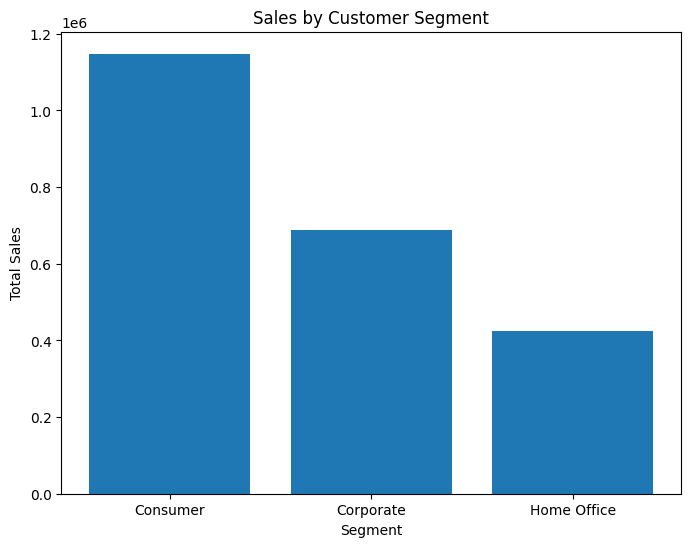

In [114]:
plt.figure(figsize=(8, 6))

plt.bar(sales_by_customer_segment["segment"], sales_by_customer_segment["total_sales_per_segment"])

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.show()

Repeat vs. One-Time (Bar Chart):

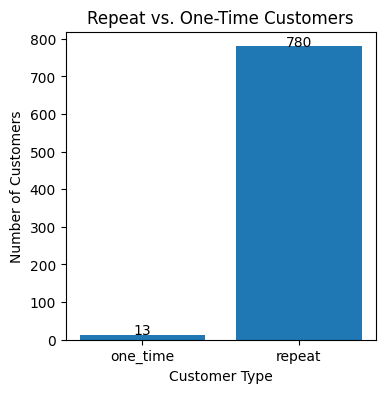

In [115]:
plt.figure(figsize=(4, 4))

plt.bar(customer_returnings["customer_type"], customer_returnings["number_of_customers"])

plt.title("Repeat vs. One-Time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

for i, v in enumerate(customer_returnings["number_of_customers"]):
    plt.text(i, v, str(v), ha='center')

plt.show()

Insights:

- The top 5 customers contribute only ~3.9% of total sales, indicating that revenue is widely distributed across the customer base and not dependent on a small number of key accounts.

- The vast majority of customers are repeat customers (~98%), suggesting strong customer retention and consistent purchasing behavior.

- The Consumer segment generates the highest total sales, followed by Corporate and Home Office, indicating that individual consumers are the primary revenue drivers.

- Although there are identifiable top customers, the relatively low concentration of sales among them suggests a diversified customer portfolio.

- The high proportion of repeat customers combined with low revenue concentration indicates a stable business model with broad customer engagement rather than reliance on a few high-value clients.